In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
out_path = 'possible_solutions_unique_0.001.csv'

# Read all entries of the csv file into a DataFrame
df = pd.read_csv(out_path)
# Refilter to ensure uniqueness (in case of multiple runs appending)
round_dec = 3
rounded = np.round(df.iloc[:, :-1].values, round_dec)
_, uniq_idx = np.unique(rounded, axis=0, return_index=True)
uniq_idx = np.sort(uniq_idx)
# Drop those with error (z > the others + 0.1)
z_values = df.iloc[uniq_idx, -1]
threshold = z_values.min() + 0.1
filtered_idx = uniq_idx[z_values <= 7.4436]

df = df.iloc[filtered_idx].reset_index(drop=True)

display(df)



,Criterion 1,Criterion 2,Criterion 3,Criterion 4,Criterion 5,Criterion 6,Criterion 7,Criterion 8,Criterion 9,Criterion 10,Criterion 11,Criterion 12,Criterion 13,Criterion 14,Criterion 15,z
0,0.651,0.058,0.058,0.074,0.003,0.001,0.001,0.005,0.050,0.052,0.038,0.001,0.001,0.007,0.001,7.443578
1,0.617,0.055,0.062,0.070,0.001,0.001,0.001,0.004,0.047,0.049,0.036,0.002,0.001,0.053,0.001,7.443578
2,0.062,0.004,0.004,0.005,0.001,0.001,0.001,0.026,0.004,0.276,0.610,0.001,0.001,0.002,0.001,7.443578
3,0.651,0.058,0.060,0.074,0.001,0.001,0.001,0.005,0.050,0.052,0.038,0.001,0.001,0.007,0.001,7.443578
4,0.063,0.004,0.004,0.005,0.001,0.001,0.001,0.019,0.005,0.445,0.448,0.001,0.001,0.001,0.001,7.443578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,0.229,0.109,0.076,0.025,0.043,0.020,0.185,0.001,0.017,0.047,0.012,0.086,0.086,0.032,0.032,7.443578
961,0.126,0.008,0.008,0.247,0.001,0.001,0.002,0.024,0.022,0.001,0.220,0.238,0.001,0.100,0.001,7.443578
962,0.607,0.054,0.054,0.068,0.001,0.006,0.066,0.004,0.046,0.048,0.035,0.001,0.001,0.006,0.001,7.443578
963,0.609,0.098,0.054,0.069,0.001,0.001,0.001,0.004,0.046,0.072,0.035,0.001,0.001,0.006,0.001,7.443578


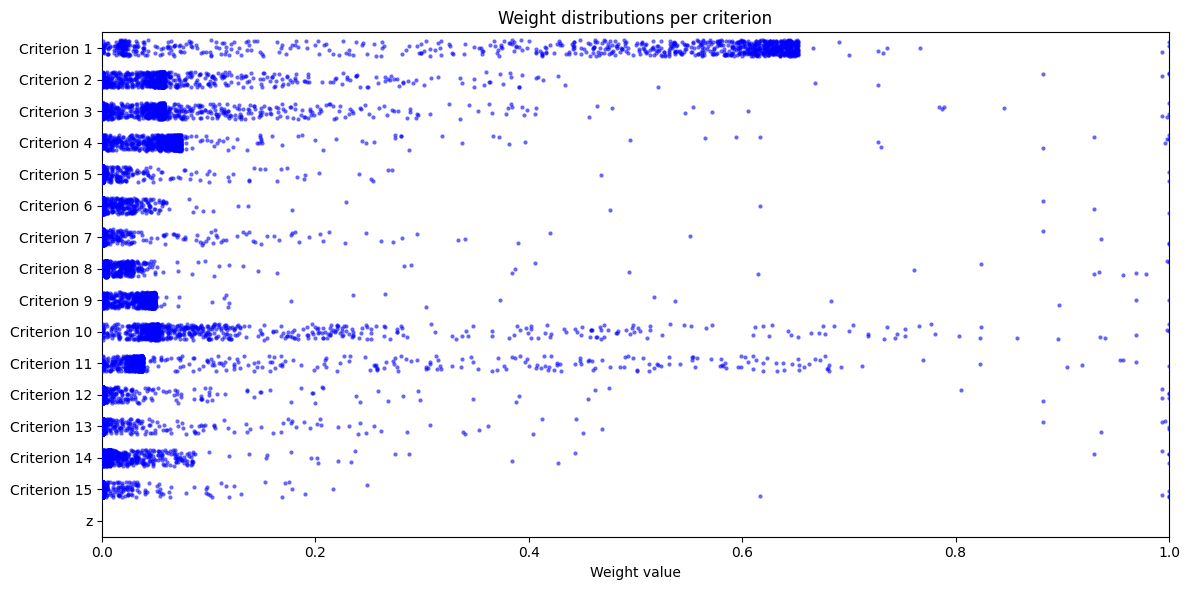

In [35]:
# Plot
plt.figure(figsize=(12, 6))
sns.stripplot(data=df, orient='h', color='b', size=3, jitter=0.25, alpha=0.6)
plt.xlabel('Weight value')
plt.title('Weight distributions per criterion')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

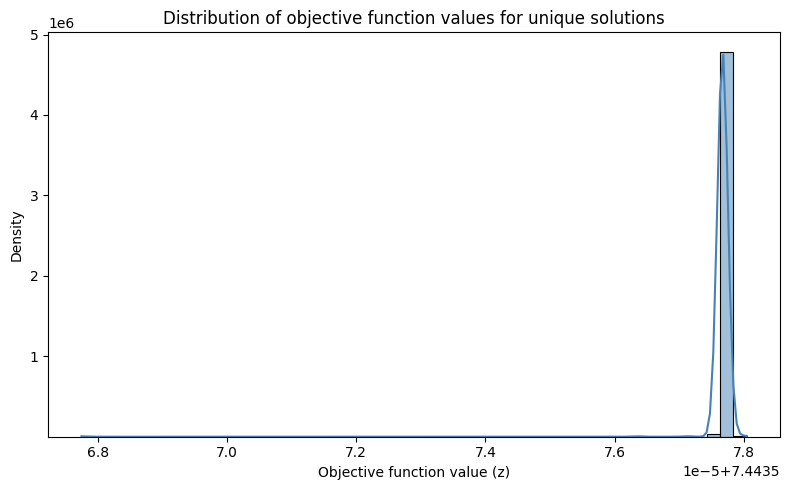

In [36]:
# Plot distribution of z values
plt.figure(figsize=(8, 5))
sns.histplot(df.iloc[:, -1][df.iloc[:, -1] > 0], bins=50, kde=True, color='steelblue', stat='density')
plt.xlabel('Objective function value (z)')
plt.ylabel('Density')
plt.ylim(1, )
# plt.yscale('log')
plt.title('Distribution of objective function values for unique solutions')
plt.tight_layout()
plt.show()


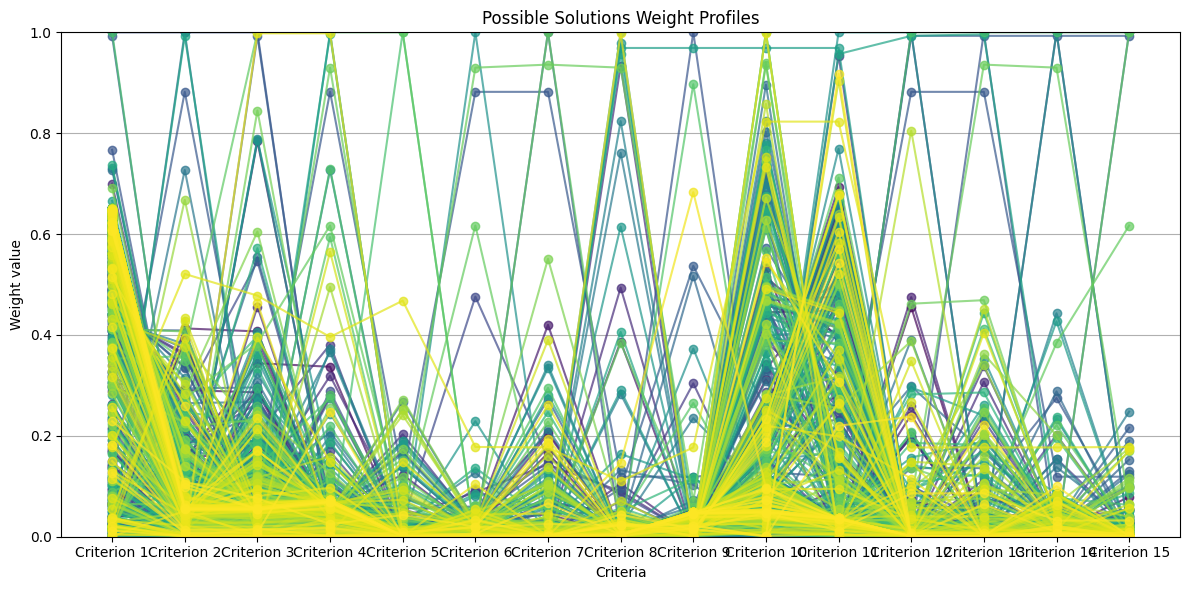

In [13]:
# Plot one solution at a time in different colors
plt.figure(figsize=(12, 6))
num_solutions = df.shape[0]
colors = plt.cm.viridis(np.linspace(0, 1, num_solutions))
for i in range(num_solutions):
    plt.plot(df.columns[:-1], df.iloc[i, :-1], marker='o', color=colors[i], alpha=0.7)
plt.xlabel('Criteria')
plt.ylabel('Weight value')
plt.title('Possible Solutions Weight Profiles')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()